# Learning Ml Models

In [2]:
import pandas as pd

In [3]:
employees=pd.read_csv('HR_comma_sep.csv')
print(employees.head(2))

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   

   salary  
0     low  
1  medium  


### Goal: Predict whether an employee will leave the company


In [4]:
employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


##### No null values

In [5]:
employees.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [6]:
employees.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [7]:
# The dataset is clean and ready for analysis.
# Next, we will perform exploratory data analysis (EDA) to understand the patterns and relationships in the data. We will visualize the distribution of the target variable (Attrition) and explore the relationships between different features and attrition.

#analyze the distribution of the target variable
employees['left'].value_counts(normalize=True)

left
0    0.761917
1    0.238083
Name: proportion, dtype: float64

In [8]:
#employee stayed= count employee who left-sum of employee who left
employees_stayed = len(employees) - employees['left'].value_counts().iloc[1]
employees_stayed

np.int64(11428)

Stayed (0) → 76.19%
Left (1) → 23.81%
class is imbalanced
** The company is experiencing a moderately high attrition rate (~24%), which indicates a potential issue in employee satisfaction, workload, or growth opportunities. **
Accuracy as evaluation metrics cannot be used

### Salary v/s Attrition

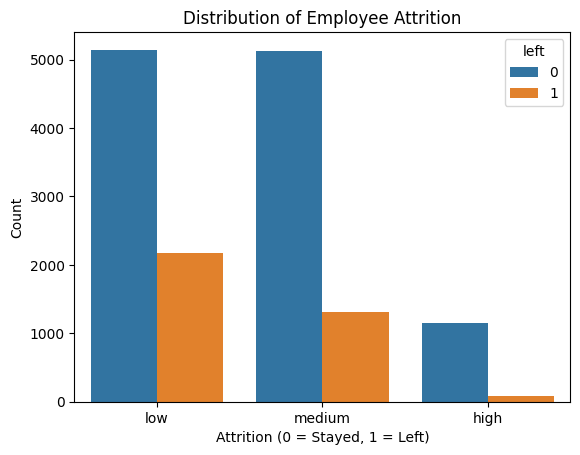

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='salary',hue='left', data=employees)
plt.title('Distribution of Employee Attrition')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Count')
plt.show()

In [10]:
pd.crosstab(employees['salary'], employees['left'], normalize='index')

left,0,1
salary,,
high,0.933711,0.066289
low,0.703116,0.296884
medium,0.795687,0.204313


### No. of project v/s attrition

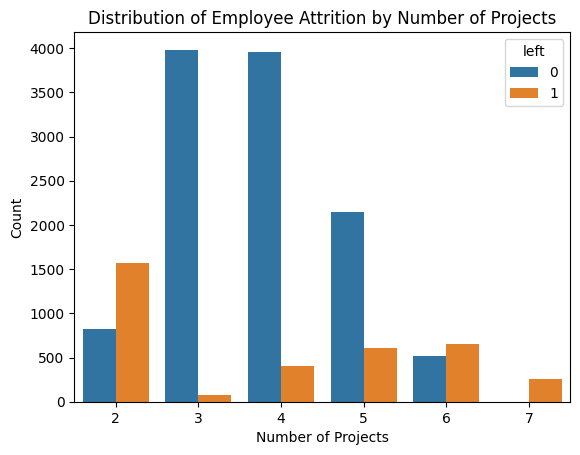

In [11]:
sns.countplot(x='number_project', hue='left', data=employees)
plt.title('Distribution of Employee Attrition by Number of Projects')
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.show()

In [12]:
pd.crosstab(employees['number_project'], employees['left'], normalize='index')

left,0,1
number_project,,
2,0.343802,0.656198
3,0.982244,0.017756
4,0.906300,0.093700
5,0.778341,0.221659
6,0.442078,0.557922
7,0.000000,1.000000


This is NOT linear.

Instead, it’s a U-shaped relationship:

1. Very low projects → HIGH attrition
2. Medium projects → LOW attrition
3. Very high projects → HIGH attrition

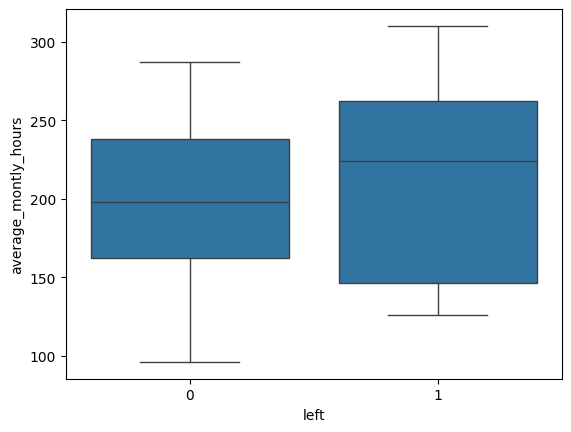

In [13]:
sns.boxplot(x='left', y='average_montly_hours', data=employees)
plt.show()

Employees who leave tend to have higher average monthly working hours compared to those who stay, indicating a potential relationship between longer working hours and increased attrition.

### Promotion V/s Attrition

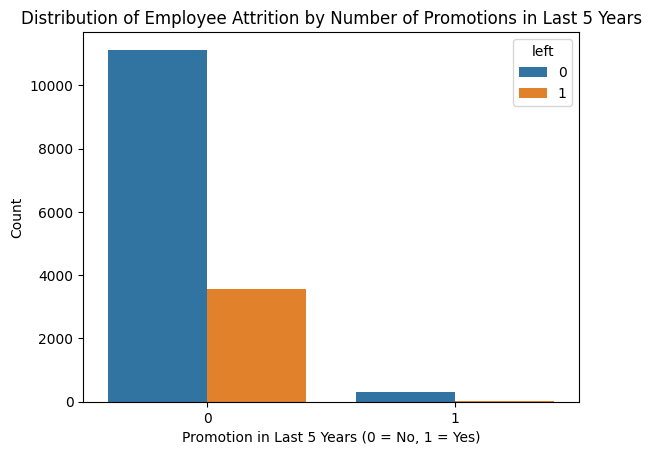

In [14]:
sns.countplot(x='promotion_last_5years',hue='left', data=employees)
plt.title('Distribution of Employee Attrition by Number of Promotions in Last 5 Years')
plt.xlabel('Promotion in Last 5 Years (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [15]:
pd.crosstab(employees['promotion_last_5years'], employees['left'], normalize='index')

left,0,1
promotion_last_5years,,
0,0.758038,0.241962
1,0.940439,0.059561


Employees who received a promotion in the last 5 years show significantly lower attrition rates compared to those who did not, indicating that career growth opportunities play an important role in employee retention.

👉 Employees who were promoted:

Very low attrition (~6%)

👉 Employees not promoted:

Much higher attrition (~24%)

Now combine everything you’ve done:
1. Low salary → higher attrition
2. Too many/few projects → higher attrition
3. Long hours → higher attrition
4. No promotion → higher attrition

Employees lacking compensation growth, career advancement, and balanced workloads are significantly more likely to leave.

### Tenure v/s attrition

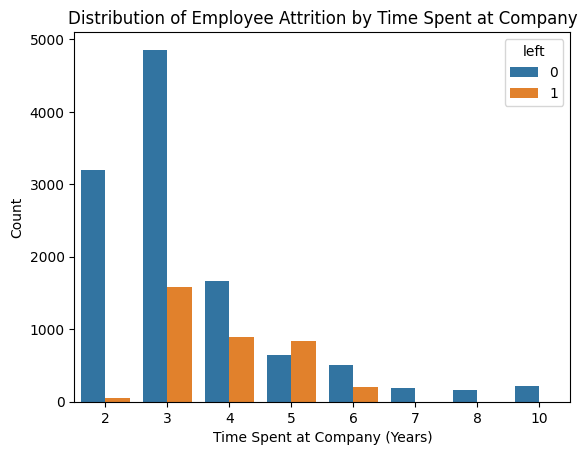

In [16]:
sns.countplot(x='time_spend_company', hue='left', data=employees)
plt.title('Distribution of Employee Attrition by Time Spent at Company')
plt.xlabel('Time Spent at Company (Years)')
plt.ylabel('Count')
plt.show()

In [17]:
pd.crosstab(employees['time_spend_company'], employees['left'], normalize='index')

left,0,1
time_spend_company,,
2,0.983662,0.016338
3,0.753841,0.246159
4,0.651936,0.348064
5,0.434487,0.565513
6,0.708914,0.291086
7,1.000000,0.000000
8,1.000000,0.000000
10,1.000000,0.000000


Employee attrition peaks around mid-tenure (approximately 4–5 years), suggesting that lack of career progression or growth opportunities at this stage may be a key factor driving employees to leave.

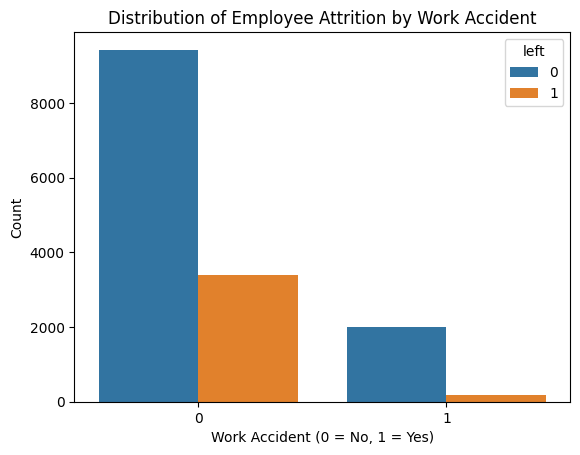

In [18]:
# we can see whether work accident related to employee attrition
sns.countplot(x='Work_accident', hue='left', data=employees)
plt.title('Distribution of Employee Attrition by Work Accident')
plt.xlabel('Work Accident (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [19]:
pd.crosstab(employees['Work_accident'], employees['left'], normalize='index')

left,0,1
Work_accident,,
0,0.734840,0.265160
1,0.922084,0.077916


How can I represent these patterns in a way a model can learn easily?

so we  use Feature Engineering 

In [20]:
employees['mid_tenure'] = employees['time_spend_company'].isin([4,5]).astype(int)

In [21]:
employees['overworked'] = (employees['average_montly_hours'] > 200).astype(int)
employees.head(2)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary,mid_tenure,overworked
0,0.38,0.53,2,157,3,0,1,0,sales,low,0,0
1,0.80,0.86,5,262,6,0,1,0,sales,medium,0,1


In [22]:
employees['project_extreme']=((employees['number_project'] <= 2) | (employees['number_project'] >= 6)).astype(int)
employees.head(2)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary,mid_tenure,overworked,project_extreme
0,0.38,0.53,2,157,3,0,1,0,sales,low,0,0,1
1,0.80,0.86,5,262,6,0,1,0,sales,medium,0,1,0


In [23]:
# encode the salary variable
employees=pd.get_dummies(employees, columns=['salary'], drop_first=True)
employees.head(2)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,mid_tenure,overworked,project_extreme,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,sales,0,0,1,True,False
1,0.80,0.86,5,262,6,0,1,0,sales,0,1,0,False,True


In [24]:
employees.drop(['Department'], axis=1, inplace=True)
employees.head(2)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,mid_tenure,overworked,project_extreme,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,1,True,False
1,0.80,0.86,5,262,6,0,1,0,0,1,0,False,True


In [25]:
from sklearn.model_selection import train_test_split
Y=employees['left']
X=employees.copy()
X.drop('left', axis=1, inplace=True)
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42,stratify=Y)

In [26]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
y_predict=model.predict(x_test)

In [28]:
from sklearn.metrics import accuracy_score,classification_report
print("Accuracy:", accuracy_score(y_test, y_predict))
print("Classification Report:\n", classification_report(y_test, y_predict))

Accuracy: 0.8623333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91      2286
           1       0.73      0.67      0.70       714

    accuracy                           0.86      3000
   macro avg       0.81      0.80      0.80      3000
weighted avg       0.86      0.86      0.86      3000



The Logistic Regression model achieved an accuracy of 86%. It performed strongly in identifying employees who stay, while achieving moderate recall (67%) for employees who leave, indicating reasonable capability in detecting attrition risk

In [29]:
# build a random forest model
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(x_train, y_train)
y_rf_predict=rf_model.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_predict))
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf_predict))

Random Forest Accuracy: 0.9906666666666667
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2286
           1       0.99      0.97      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [30]:
importance = rf_model.feature_importances_

for feature, score in zip(X.columns, importance):
    print(f"{feature}: {score*100:.2f}%")

satisfaction_level: 27.76%
last_evaluation: 11.85%
number_project: 11.00%
average_montly_hours: 11.99%
time_spend_company: 13.88%
Work_accident: 0.63%
promotion_last_5years: 0.12%
mid_tenure: 4.93%
overworked: 2.62%
project_extreme: 14.29%
salary_low: 0.58%
salary_medium: 0.35%


Employee attrition is primarily driven by employee satisfaction, workload imbalance, and tenure-related factors. Employees with extreme project loads and lower satisfaction levels are significantly more likely to leave

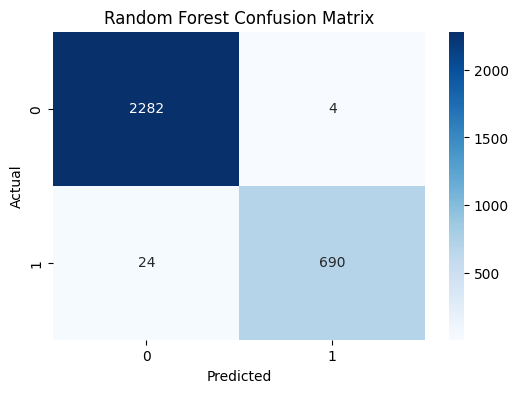

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_rf_predict)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')

plt.show()

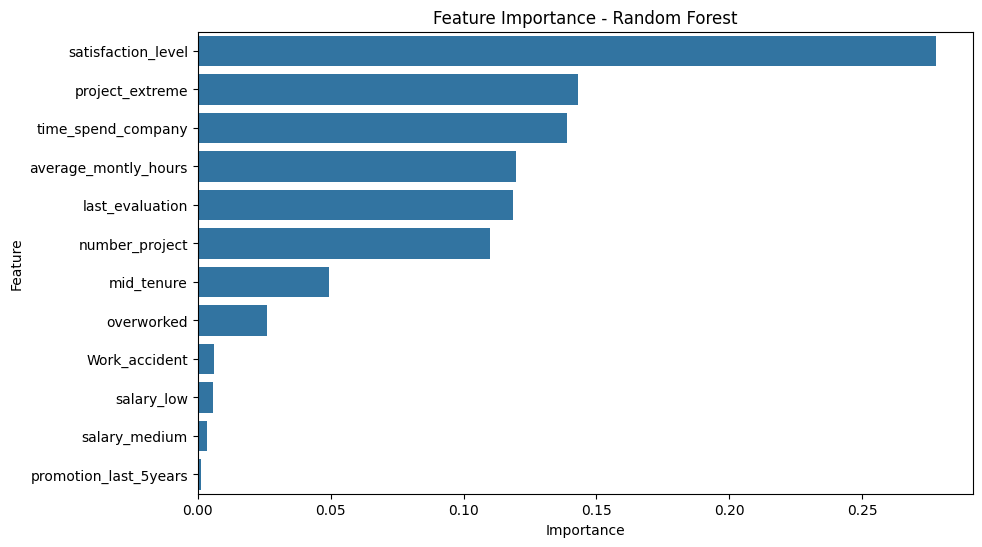

In [32]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance - Random Forest')
plt.show()